# Define maze dataset

In [1]:
import numpy as np
import pandas as pd
import subprocess
from pathlib import Path

In [2]:
MAZE_LAYOUTS = {
    "OPEN": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "U_MAZE": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 0, 1, 1, 1, 1, 1], [1, 1, 0, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "U_MAZE_EVAL": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 0, 1, 1], [1, 1, 1, 1, 1, 0, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "SMALL_MAZE": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "MEDIUM_MAZE": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 1, 1, 0, 0, 1], [1, 0, 0, 0, 1, 0, 0, 1], [1, 1, 1, 0, 0, 0, 1, 1], [1, 0, 0, 0, 1, 0, 0, 1], [1, 0, 1, 0, 0, 1, 0, 1], [1, 0, 0, 1, 0, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "MEDIUM_MAZE_EVAL": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 0, 0, 0, 0, 1], [1, 0, 1, 1, 0, 1, 0, 1], [1, 0, 1, 0, 0, 0, 0, 1], [1, 1, 1, 0, 0, 1, 1, 1], [1, 0, 0, 0, 0, 0, 0, 1], [1, 0, 0, 1, 1, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "LARGE_MAZE": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1], [1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1], [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1], [1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1], [1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1], [1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1], [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "LARGE_MAZE_EVAL": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], [1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1], [1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1], [1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1], [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1], [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1], [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
}


In [3]:
maze_names = np.array(list(MAZE_LAYOUTS.keys()), dtype="<U32")
grid_shapes = np.array([maze.shape for maze in MAZE_LAYOUTS.values()], dtype=np.int32)
mazes = np.empty(len(maze_names), dtype=object)
for index, maze_name in enumerate(maze_names):
    mazes[index] = MAZE_LAYOUTS[str(maze_name)].copy()


In [4]:
dataset_path = Path("maze2d_discrete_8x8_dataset_v2.npz")
np.savez(
    dataset_path,
    maze_names=np.array(maze_names, dtype="<U32"),
    mazes=mazes,
    grid_shapes=grid_shapes,
)

print(dataset_path)


maze2d_discrete_8x8_dataset_v2.npz


# Get trajectory data to feed into transformers

In [5]:
OUTPUT_DATASET = Path("maze2d_all_mazes_transformer_ready_4act.npz")
PAD_TOKEN_ID = 0
ACTION_TOKEN_NAMES = np.array(["UP", "DOWN", "LEFT", "RIGHT"])
ACTION_DELTAS = np.asarray(
    [
        [0, 1],
        [0, -1],
        [-1, 0],
        [1, 0],
    ],
    dtype=np.int8,
)
TOKEN_TYPE_PAD = 0
TOKEN_TYPE_MAZE = 1
TOKEN_TYPE_START = 2
TOKEN_TYPE_GOAL = 3
TOKEN_TYPE_STATE = 4
TOKEN_TYPE_ACTION = 5

In [6]:
def cell_to_state_index(cell_xy: np.ndarray, global_grid_shape: tuple[int, int]) -> int:
    return int(cell_xy[0]) * int(global_grid_shape[1]) + int(cell_xy[1])


def bfs_shortest_path(maze: np.ndarray, start: tuple[int, int], goal: tuple[int, int]) -> np.ndarray | None:
    if start == goal:
        return np.asarray([start], dtype=np.int16)

    rows, cols = maze.shape
    queue: deque[tuple[int, int]] = deque([start])
    parents: dict[tuple[int, int], tuple[int, int] | None] = {start: None}
    neighbor_order = ((0, 1), (0, -1), (-1, 0), (1, 0))

    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for dx, dy in neighbor_order:
            nxt = (current[0] + dx, current[1] + dy)
            inside = 0 <= nxt[0] < rows and 0 <= nxt[1] < cols
            if not inside or maze[nxt] != 0 or nxt in parents:
                continue
            parents[nxt] = current
            queue.append(nxt)

    if goal not in parents:
        return None

    path_rev = []
    node: tuple[int, int] | None = goal
    while node is not None:
        path_rev.append(node)
        node = parents[node]
    path_rev.reverse()
    return np.asarray(path_rev, dtype=np.int16)


def build_tokenized_episode(
    maze_token_id: int,
    path_cells: np.ndarray,
    goal_cell: np.ndarray,
    global_grid_shape: tuple[int, int],
    state_token_offset: int,
    action_token_offset: int,
) -> dict[str, np.ndarray | int]:
    def state_token(cell_xy: np.ndarray) -> int:
        return state_token_offset + cell_to_state_index(cell_xy, global_grid_shape)

    obs_xy = np.asarray(path_cells, dtype=np.int16)
    actions = np.diff(obs_xy, axis=0).astype(np.int8) if len(obs_xy) > 1 else np.zeros((0, 2), dtype=np.int8)
    action_delta_to_token = {
        tuple(int(v) for v in delta): int(action_token_offset + idx)
        for idx, delta in enumerate(ACTION_DELTAS)
    }

    input_ids = [maze_token_id, state_token(obs_xy[0]), state_token(goal_cell), state_token(obs_xy[0])]
    token_type_ids = [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE]
    labels = [-100, -100, -100, -100]

    for step in range(len(obs_xy) - 1):
        action_key = tuple(int(v) for v in actions[step])
        action_token = action_delta_to_token[action_key]
        next_state_token = state_token(obs_xy[step + 1])
        input_ids.extend([action_token, next_state_token])
        token_type_ids.extend([TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE])
        labels.extend([action_token, -100])

    return {
        "input_ids": np.asarray(input_ids, dtype=np.int32),
        "labels": np.asarray(labels, dtype=np.int32),
        "token_type_ids": np.asarray(token_type_ids, dtype=np.int8),
        "sequence_length": int(len(input_ids)),
        "path_length": int(len(obs_xy)),
    }

In [7]:
dataset = np.load(dataset_path, allow_pickle=True)
maze_names = np.asarray(dataset["maze_names"])
mazes = dataset["mazes"]
grid_shapes = np.asarray(dataset["grid_shapes"], dtype=np.int32)
num_mazes = int(len(maze_names))
global_grid_shape = (
    int(grid_shapes[:, 0].max()),
    int(grid_shapes[:, 1].max()),
)

maze_token_offset = 1
state_token_offset = maze_token_offset + num_mazes
num_state_tokens = int(global_grid_shape[0] * global_grid_shape[1])
action_token_offset = state_token_offset + num_state_tokens
vocab_size = action_token_offset + len(ACTION_DELTAS)

episode_input_ids: list[np.ndarray] = []
episode_labels: list[np.ndarray] = []
episode_token_types: list[np.ndarray] = []
sequence_lengths: list[int] = []
path_lengths: list[int] = []
maze_indices: list[int] = []
maze_name_per_episode: list[str] = []
grid_shape_per_episode: list[np.ndarray] = []
start_cells: list[np.ndarray] = []
goal_cells: list[np.ndarray] = []
paths_xy: list[np.ndarray] = []

episode_id = 0
connected_pair_count = 0
skipped_pair_count = 0

In [8]:
from collections import deque
for maze_index, (maze_name, maze_obj, grid_shape) in enumerate(zip(maze_names, mazes, grid_shapes)):
        maze = np.asarray(maze_obj, dtype=np.int8)
        free_cells = np.argwhere(maze == 0).astype(np.int16)
        maze_token_id = int(maze_token_offset + maze_index)

       
        for start_cell in free_cells:
            for goal_cell in free_cells:
                if np.array_equal(start_cell, goal_cell):
                    continue

                path_cells = bfs_shortest_path(
                    maze=maze,
                    start=tuple(int(v) for v in start_cell),
                    goal=tuple(int(v) for v in goal_cell),
                )
                if path_cells is None:
                    skipped_pair_count += 1
                    continue

                packed = build_tokenized_episode(
                    maze_token_id=maze_token_id,
                    path_cells=path_cells,
                    goal_cell=np.asarray(goal_cell, dtype=np.int16),
                    global_grid_shape=global_grid_shape,
                    state_token_offset=state_token_offset,
                    action_token_offset=action_token_offset,
                )
                episode_input_ids.append(packed["input_ids"])
                episode_labels.append(packed["labels"])
                episode_token_types.append(packed["token_type_ids"])
                sequence_lengths.append(int(packed["sequence_length"]))
                path_lengths.append(int(packed["path_length"]))
                maze_indices.append(int(maze_index))
                maze_name_per_episode.append(str(maze_name))
                grid_shape_per_episode.append(np.asarray(grid_shape, dtype=np.int32))
                start_cells.append(np.asarray(start_cell, dtype=np.int16))
                goal_cells.append(np.asarray(goal_cell, dtype=np.int16))
                paths_xy.append(np.asarray(path_cells, dtype=np.int16))
                connected_pair_count += 1
                episode_id += 1

sequence_lengths_arr = np.asarray(sequence_lengths, dtype=np.int32)
max_seq_len = int(sequence_lengths_arr.max())
num_episodes = int(len(episode_input_ids))

input_ids = np.full((num_episodes, max_seq_len), PAD_TOKEN_ID, dtype=np.int32)
labels = np.full((num_episodes, max_seq_len), -100, dtype=np.int32)
attention_mask = np.zeros((num_episodes, max_seq_len), dtype=np.int8)
token_type_ids = np.full((num_episodes, max_seq_len), TOKEN_TYPE_PAD, dtype=np.int8)

for idx in range(num_episodes):
    seq_len = int(sequence_lengths_arr[idx])
    input_ids[idx, :seq_len] = episode_input_ids[idx]
    labels[idx, :seq_len] = episode_labels[idx]
    token_type_ids[idx, :seq_len] = episode_token_types[idx]
    attention_mask[idx, :seq_len] = 1

np.savez_compressed(
    OUTPUT_DATASET,
    input_ids=input_ids,
    labels=labels,
    attention_mask=attention_mask,
    token_type_ids=token_type_ids,
    sequence_lengths=sequence_lengths_arr,
    path_lengths=np.asarray(path_lengths, dtype=np.int32),
    episode_ids=np.arange(num_episodes, dtype=np.int32),
    maze_indices=np.asarray(maze_indices, dtype=np.int32),
    maze_names=maze_names.astype("<U32"),
    maze_name_per_episode=np.asarray(maze_name_per_episode, dtype="<U32"),
    maze_token_ids=np.arange(maze_token_offset, maze_token_offset + num_mazes, dtype=np.int32),
    mazes=mazes,
    grid_shapes=grid_shapes.astype(np.int32),
    grid_shape_per_episode=np.asarray(grid_shape_per_episode, dtype=np.int32),
    start_cells=np.asarray(start_cells, dtype=np.int16),
    goal_cells=np.asarray(goal_cells, dtype=np.int16),
    paths_xy=np.asarray(paths_xy, dtype=object),
    pad_token_id=np.asarray([PAD_TOKEN_ID], dtype=np.int32),
    vocab_size=np.asarray([vocab_size], dtype=np.int32),
    maze_token_offset=np.asarray([maze_token_offset], dtype=np.int32),
    state_token_offset=np.asarray([state_token_offset], dtype=np.int32),
    action_token_offset=np.asarray([action_token_offset], dtype=np.int32),
    global_grid_shape=np.asarray(global_grid_shape, dtype=np.int32),
    action_token_names=ACTION_TOKEN_NAMES,
    action_deltas=ACTION_DELTAS,
    token_type_pad=np.asarray([TOKEN_TYPE_PAD], dtype=np.int8),
    token_type_maze=np.asarray([TOKEN_TYPE_MAZE], dtype=np.int8),
    token_type_start=np.asarray([TOKEN_TYPE_START], dtype=np.int8),
    token_type_goal=np.asarray([TOKEN_TYPE_GOAL], dtype=np.int8),
    token_type_state=np.asarray([TOKEN_TYPE_STATE], dtype=np.int8),
    token_type_action=np.asarray([TOKEN_TYPE_ACTION], dtype=np.int8),
)


print("output_dataset:", OUTPUT_DATASET)
print("num_mazes:", num_mazes)
print("maze_names:", [str(name) for name in maze_names])
print("global_grid_shape:", global_grid_shape)
print("num_episodes:", num_episodes)
print("connected_pair_count:", connected_pair_count)
print("skipped_pair_count:", skipped_pair_count)
print("max_seq_len:", max_seq_len)
print("vocab_size:", vocab_size)

output_dataset: maze2d_all_mazes_transformer_ready_4act.npz
num_mazes: 8
maze_names: ['OPEN', 'U_MAZE', 'U_MAZE_EVAL', 'SMALL_MAZE', 'MEDIUM_MAZE', 'MEDIUM_MAZE_EVAL', 'LARGE_MAZE', 'LARGE_MAZE_EVAL']
global_grid_shape: (9, 12)
num_episodes: 5976
connected_pair_count: 5976
skipped_pair_count: 32
max_seq_len: 42
vocab_size: 121


In [9]:
NUM_FOLDS = 5

SOURCE_DATASET = Path("maze2d_all_mazes_transformer_ready_4act.npz")
OUTPUT_DATASET = Path("maze2d_all_mazes_transformer_ready_4act_cv5.npz")

data = np.load(SOURCE_DATASET, allow_pickle=True)
files = list(data.files)
files

['input_ids',
 'labels',
 'attention_mask',
 'token_type_ids',
 'sequence_lengths',
 'path_lengths',
 'episode_ids',
 'maze_indices',
 'maze_names',
 'maze_name_per_episode',
 'maze_token_ids',
 'mazes',
 'grid_shapes',
 'grid_shape_per_episode',
 'start_cells',
 'goal_cells',
 'paths_xy',
 'pad_token_id',
 'vocab_size',
 'maze_token_offset',
 'state_token_offset',
 'action_token_offset',
 'global_grid_shape',
 'action_token_names',
 'action_deltas',
 'token_type_pad',
 'token_type_maze',
 'token_type_start',
 'token_type_goal',
 'token_type_state',
 'token_type_action']

In [10]:
data = np.load(SOURCE_DATASET, allow_pickle=True)
files = list(data.files)

maze_name_per_episode = np.asarray(data["maze_name_per_episode"]).astype("<U32")
start_cells = np.asarray(data["start_cells"], dtype=np.int16)
goal_cells = np.asarray(data["goal_cells"], dtype=np.int16)
path_lengths = np.asarray(data["path_lengths"], dtype=np.int32)

num_episodes = int(len(maze_name_per_episode))
fold_ids = np.zeros(num_episodes, dtype=np.int32)

unique_mazes = list(dict.fromkeys(str(name) for name in maze_name_per_episode))
per_maze_rows: list[dict[str, object]] = []

for maze_name in unique_mazes:
    maze_idx = np.flatnonzero(maze_name_per_episode == maze_name)
    sort_order = np.lexsort(
        (
            goal_cells[maze_idx, 1],
            goal_cells[maze_idx, 0],
            start_cells[maze_idx, 1],
            start_cells[maze_idx, 0],
            path_lengths[maze_idx],
        )
    )
    maze_sorted_idx = maze_idx[sort_order]
    assigned_folds = np.arange(int(maze_sorted_idx.size), dtype=np.int32) % NUM_FOLDS
    fold_ids[maze_sorted_idx] = assigned_folds

    per_maze_rows.append(
        {
            "maze_name": maze_name,
            "total": int(maze_sorted_idx.size),
            "fold_counts": [int(np.sum(assigned_folds == fold)) for fold in range(NUM_FOLDS)],
        }
    )

out: dict[str, np.ndarray] = {key: data[key] for key in files}
out["fold_ids"] = fold_ids
out["cv_num_folds"] = np.asarray([NUM_FOLDS], dtype=np.int32)
out["cv_split_method"] = np.asarray(["round_robin_lexsorted_per_maze"], dtype="<U64")

np.savez_compressed(OUTPUT_DATASET, **out)

print("source_dataset:", SOURCE_DATASET)
print("output_dataset:", OUTPUT_DATASET)
print("cv_num_folds:", NUM_FOLDS)
print("cv_split_method: round_robin_lexsorted_per_maze")
print("num_episodes:", num_episodes)
for row in per_maze_rows:
    print(row)

source_dataset: maze2d_all_mazes_transformer_ready_4act.npz
output_dataset: maze2d_all_mazes_transformer_ready_4act_cv5.npz
cv_num_folds: 5
cv_split_method: round_robin_lexsorted_per_maze
num_episodes: 5976
{'maze_name': 'OPEN', 'total': 240, 'fold_counts': [48, 48, 48, 48, 48]}
{'maze_name': 'U_MAZE', 'total': 90, 'fold_counts': [18, 18, 18, 18, 18]}
{'maze_name': 'U_MAZE_EVAL', 'total': 90, 'fold_counts': [18, 18, 18, 18, 18]}
{'maze_name': 'SMALL_MAZE', 'total': 24, 'fold_counts': [5, 5, 5, 5, 4]}
{'maze_name': 'MEDIUM_MAZE', 'total': 650, 'fold_counts': [130, 130, 130, 130, 130]}
{'maze_name': 'MEDIUM_MAZE_EVAL', 'total': 650, 'fold_counts': [130, 130, 130, 130, 130]}
{'maze_name': 'LARGE_MAZE', 'total': 2070, 'fold_counts': [414, 414, 414, 414, 414]}
{'maze_name': 'LARGE_MAZE_EVAL', 'total': 2162, 'fold_counts': [433, 433, 432, 432, 432]}


In [11]:
from __future__ import annotations

import argparse
import json
import math
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [12]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


class MazeTokenDataset(Dataset):
    def __init__(self, npz_path: Path, indices: np.ndarray) -> None:
        data = np.load(npz_path, allow_pickle=True)
        self.input_ids = torch.from_numpy(data["input_ids"][indices].astype(np.int64))
        self.labels = torch.from_numpy(data["labels"][indices].astype(np.int64))
        self.attention_mask = torch.from_numpy(data["attention_mask"][indices].astype(np.bool_))
        self.token_type_ids = torch.from_numpy(data["token_type_ids"][indices].astype(np.int64))
        self.sequence_lengths = torch.from_numpy(data["sequence_lengths"][indices].astype(np.int64))
        self.episode_ids = torch.from_numpy(data["episode_ids"][indices].astype(np.int64))

        self.vocab_size = int(data["vocab_size"][0])
        self.pad_token_id = int(data["pad_token_id"][0])
        self.state_token_offset = int(data["state_token_offset"][0])
        self.action_token_offset = int(data["action_token_offset"][0])
        grid_key = "grid_shape" if "grid_shape" in data.files else "global_grid_shape"
        self.grid_shape = tuple(int(v) for v in data[grid_key])
        self.action_token_names = [str(v) for v in data["action_token_names"]]
        self.action_deltas = np.asarray(data["action_deltas"], dtype=np.int64)
    def __len__(self) -> int:
        return int(self.input_ids.shape[0])

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        return {
            "input_ids": self.input_ids[idx],
            "labels": self.labels[idx],
            "attention_mask": self.attention_mask[idx],
            "token_type_ids": self.token_type_ids[idx],
            "sequence_lengths": self.sequence_lengths[idx],
            "episode_id": self.episode_ids[idx],
        }

In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int) -> None:
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]

In [14]:
class TinyCausalTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_seq_len: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        num_token_types: int = 6,
    ) -> None:
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.type_embed = nn.Embedding(num_token_types, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_seq_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        x = self.token_embed(input_ids) + self.type_embed(token_type_ids)
        x = self.pos_encoder(x)
        seq_len = input_ids.size(1)
        causal_mask = torch.triu(
            torch.ones((seq_len, seq_len), dtype=torch.bool, device=input_ids.device),
            diagonal=1,
        )
        x = self.encoder(x, mask=causal_mask, src_key_padding_mask=~attention_mask)
        x = self.norm(x)
        return self.lm_head(x)

In [15]:
@dataclass
class EvalMetrics:
    loss: float
    action_accuracy: float


def shifted_loss_and_accuracy(
    logits: torch.Tensor,
    labels: torch.Tensor,
    ignore_index: int = -100,
) -> tuple[torch.Tensor, float]:
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        ignore_index=ignore_index,
    )
    with torch.no_grad():
        valid = shift_labels != ignore_index
        if valid.any():
            preds = shift_logits.argmax(dim=-1)
            acc = (preds[valid] == shift_labels[valid]).float().mean().item()
        else:
            acc = float("nan")
    return loss, acc

In [16]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
) -> EvalMetrics:
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_acc = 0.0
    steps = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask)
            loss, acc = shifted_loss_and_accuracy(logits, labels)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss += float(loss.item())
        total_acc += float(acc)
        steps += 1

    return EvalMetrics(loss=total_loss / max(steps, 1), action_accuracy=total_acc / max(steps, 1))


In [17]:
def decode_token(token_id: int, action_token_offset: int, action_token_names: list[str]) -> str:
    if token_id < action_token_offset:
        return f"STATE_{token_id}"
    return f"ACTION_{action_token_names[token_id - action_token_offset]}"


def greedy_generate_actions(
    model: TinyCausalTransformer,
    dataset: MazeTokenDataset,
    device: torch.device,
    episode_index: int,
    max_steps: int = 16,
) -> dict[str, object]:
    input_ids_full = dataset.input_ids[episode_index].numpy()
    labels_full = dataset.labels[episode_index].numpy()
    token_types_full = dataset.token_type_ids[episode_index].numpy()
    seq_len = int(dataset.sequence_lengths[episode_index].item())

    action_positions = np.flatnonzero(labels_full[:seq_len] != -100)
    prompt_end = 4  # [MAZE, START, GOAL, STATE_0]
    generated = input_ids_full[:prompt_end].tolist()
    generated_types = token_types_full[:prompt_end].tolist()
    target_actions = []
    pred_actions = []

    model.eval()
    for step_idx, action_pos in enumerate(action_positions[:max_steps]):
        x = torch.tensor([generated], dtype=torch.long, device=device)
        t = torch.tensor([generated_types], dtype=torch.long, device=device)
        m = torch.ones_like(x, dtype=torch.bool, device=device)
        with torch.no_grad():
            logits = model(input_ids=x, token_type_ids=t, attention_mask=m)
        action_logits = logits[0, -1, dataset.action_token_offset : dataset.action_token_offset + len(dataset.action_token_names)]
        next_token = int(dataset.action_token_offset + action_logits.argmax().item())
        target_token = int(labels_full[action_pos])
        pred_actions.append(next_token)
        target_actions.append(target_token)

        # Append predicted action, but keep the true next state as context so rollout stays on-manifold.
        generated.append(next_token)
        generated_types.append(5)
        next_state_pos = int(action_pos + 1)
        if next_state_pos >= seq_len:
            break
        generated.append(int(input_ids_full[next_state_pos]))
        generated_types.append(int(token_types_full[next_state_pos]))

    return {
        "episode_id": int(dataset.episode_ids[episode_index].item()),
        "target_action_tokens": target_actions,
        "pred_action_tokens": pred_actions,
        "target_actions_named": [
            decode_token(tok, dataset.action_token_offset, dataset.action_token_names) for tok in target_actions
        ],
        "pred_actions_named": [
            decode_token(tok, dataset.action_token_offset, dataset.action_token_names) for tok in pred_actions
        ],
    }

In [18]:
TRAIN_DATASET_PATH = Path("maze2d_all_mazes_transformer_ready_4act_cv5.npz")
DEFAULT_CHECKPOINT_PATH = Path("checkpoints/maze2d_discrete_transformer_tiny.pt")


def build_train_val_indices(
    dataset_path: Path,
    seed: int = 7,
    max_train_episodes: int = 4096,
    max_val_episodes: int = 512,
    use_predefined_split: bool = False,
    train_mask_key: str = "train_mask",
    val_mask_key: str = "eval_mask",
    cv_fold: int | None = None,
    fold_ids_key: str = "fold_ids",
) -> tuple[np.ndarray, np.ndarray]:
    data = np.load(dataset_path, allow_pickle=True)
    num_episodes = int(data["input_ids"].shape[0])

    if cv_fold is not None:
        if fold_ids_key not in data.files:
            raise KeyError(f"Requested cv fold split, but dataset is missing {fold_ids_key!r}.")
        fold_ids = np.asarray(data[fold_ids_key], dtype=np.int32)
        train_idx_all = np.flatnonzero(fold_ids != int(cv_fold))
        val_idx_all = np.flatnonzero(fold_ids == int(cv_fold))
        train_count = min(max_train_episodes, int(train_idx_all.size))
        val_count = min(max_val_episodes, int(val_idx_all.size))
        return train_idx_all[:train_count], val_idx_all[:val_count]

    if use_predefined_split:
        if train_mask_key not in data.files or val_mask_key not in data.files:
            raise KeyError(
                f"Requested predefined split, but dataset is missing {train_mask_key!r} or {val_mask_key!r}."
            )
        train_idx_all = np.flatnonzero(np.asarray(data[train_mask_key], dtype=np.bool_))
        val_idx_all = np.flatnonzero(np.asarray(data[val_mask_key], dtype=np.bool_))
        train_count = min(max_train_episodes, int(train_idx_all.size))
        val_count = min(max_val_episodes, int(val_idx_all.size))
        return train_idx_all[:train_count], val_idx_all[:val_count]

    perm = np.random.RandomState(seed).permutation(num_episodes)
    val_count = min(max_val_episodes, max(1, num_episodes // 10))
    train_count = min(max_train_episodes, num_episodes - val_count)
    train_idx = perm[:train_count]
    val_idx = perm[train_count : train_count + val_count]
    return train_idx, val_idx


def train_transformer_experiment(
    dataset_path: Path,
    output_path: Path,
    epochs: int = 12,
    batch_size: int = 128,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    d_model: int = 64,
    nhead: int = 4,
    num_layers: int = 2,
    ffn_dim: int = 128,
    dropout: float = 0.1,
    max_train_episodes: int = 4096,
    max_val_episodes: int = 512,
    use_predefined_split: bool = False,
    train_mask_key: str = "train_mask",
    val_mask_key: str = "eval_mask",
    cv_fold: int | None = None,
    fold_ids_key: str = "fold_ids",
    seed: int = 7,
    device: str = "cpu",
) -> dict[str, object]:
    set_seed(seed)
    torch_device = torch.device(device)

    train_idx, val_idx = build_train_val_indices(
        dataset_path=dataset_path,
        seed=seed,
        max_train_episodes=max_train_episodes,
        max_val_episodes=max_val_episodes,
        use_predefined_split=use_predefined_split,
        train_mask_key=train_mask_key,
        val_mask_key=val_mask_key,
        cv_fold=cv_fold,
        fold_ids_key=fold_ids_key,
    )

    train_ds = MazeTokenDataset(dataset_path, train_idx)
    val_ds = MazeTokenDataset(dataset_path, val_idx)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = TinyCausalTransformer(
        vocab_size=train_ds.vocab_size,
        max_seq_len=train_ds.input_ids.shape[1],
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=ffn_dim,
        dropout=dropout,
    ).to(torch_device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    print(
        json.dumps(
            {
                "dataset": str(dataset_path),
                "train_episodes": len(train_ds),
                "val_episodes": len(val_ds),
                "seq_len": int(train_ds.input_ids.shape[1]),
                "vocab_size": train_ds.vocab_size,
                "device": str(torch_device),
                "cv_fold": cv_fold,
            },
            indent=2,
        )
    )

    best_val = float("inf")
    best_checkpoint = None
    history: list[dict[str, float]] = []
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer, torch_device)
        val_metrics = run_epoch(model, val_loader, None, torch_device)
        row = {
            "epoch": float(epoch),
            "train_loss": train_metrics.loss,
            "train_action_accuracy": train_metrics.action_accuracy,
            "val_loss": val_metrics.loss,
            "val_action_accuracy": val_metrics.action_accuracy,
        }
        history.append(row)
        print(
            f"epoch {epoch:02d} | "
            f"train_loss={train_metrics.loss:.4f} train_acc={train_metrics.action_accuracy:.4f} | "
            f"val_loss={val_metrics.loss:.4f} val_acc={val_metrics.action_accuracy:.4f}"
        )
        if val_metrics.loss < best_val:
            best_val = val_metrics.loss
            best_checkpoint = {
                "model_state_dict": model.state_dict(),
                "model_config": {
                    "vocab_size": train_ds.vocab_size,
                    "max_seq_len": int(train_ds.input_ids.shape[1]),
                    "d_model": d_model,
                    "nhead": nhead,
                    "num_layers": num_layers,
                    "dim_feedforward": ffn_dim,
                    "dropout": dropout,
                },
                "history": list(history),
            }
            output_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(best_checkpoint, output_path)

    preview = greedy_generate_actions(model, val_ds, torch_device, episode_index=0)
    print("preview rollout:", json.dumps(preview, indent=2))
    print("saved checkpoint:", output_path)

    return {
        "model": model,
        "train_dataset": train_ds,
        "val_dataset": val_ds,
        "history": history,
        "best_checkpoint": best_checkpoint,
        "output_path": output_path,
        "preview": preview,
        "device": torch_device,
    }


In [19]:
single_run = train_transformer_experiment(
    dataset_path=TRAIN_DATASET_PATH,
    output_path=DEFAULT_CHECKPOINT_PATH,
    epochs=20,
    batch_size=128,
    lr=3e-4,
    weight_decay=1e-4,
    d_model=64,
    nhead=4,
    num_layers=2,
    ffn_dim=128,
    dropout=0.1,
    max_train_episodes=4096,
    max_val_episodes=512,
    seed=7,
    device="cpu",
)


{
  "dataset": "maze2d_all_mazes_transformer_ready_4act_cv5.npz",
  "train_episodes": 4096,
  "val_episodes": 512,
  "seq_len": 42,
  "vocab_size": 121,
  "device": "cpu",
  "cv_fold": null
}


epoch 01 | train_loss=3.6058 train_acc=0.2000 | val_loss=2.5199 val_acc=0.3379


epoch 02 | train_loss=2.1202 train_acc=0.3646 | val_loss=1.7037 val_acc=0.4542


epoch 03 | train_loss=1.5068 train_acc=0.4548 | val_loss=1.2573 val_acc=0.5193


epoch 04 | train_loss=1.1360 train_acc=0.5657 | val_loss=0.9529 val_acc=0.6451


...

epoch 16 | train_loss=0.3623 train_acc=0.8594 | val_loss=0.2755 val_acc=0.8976


epoch 17 | train_loss=0.3389 train_acc=0.8685 | val_loss=0.2541 val_acc=0.9066


epoch 18 | train_loss=0.3215 train_acc=0.8765 | val_loss=0.2356 val_acc=0.9131


epoch 19 | train_loss=0.3040 train_acc=0.8825 | val_loss=0.2220 val_acc=0.9193


epoch 20 | train_loss=0.2861 train_acc=0.8894 | val_loss=0.2075 val_acc=0.9258
preview rollout: {
  "episode_id": 4760,
  "target_action_tokens": [
    120,
    117,
    117
  ],
  "pred_action_tokens": [
    120,
    117,
    117
  ],
  "target_actions_named": [
    "ACTION_RIGHT",
    "ACTION_UP",
    "ACTION_UP"
  ],
  "pred_actions_named": [
    "ACTION_RIGHT",
    "ACTION_UP",
    "ACTION_UP"
  ]
}
saved checkpoint: checkpoints\maze2d_discrete_transformer_tiny.pt


In [20]:
CV_DATASET_PATH = Path("maze2d_all_mazes_transformer_ready_4act_cv5.npz")
CV_CHECKPOINT_DIR = Path("checkpoints")
CV_FOLDS = range(5)
DEFAULT_MAZES = ["OPEN", "U_MAZE", "U_MAZE_EVAL", "SMALL_MAZE", "MEDIUM_MAZE", "MEDIUM_MAZE_EVAL", "LARGE_MAZE", "LARGE_MAZE_EVAL"]
TOKEN_TYPE_MAZE = 1
TOKEN_TYPE_START = 2
TOKEN_TYPE_GOAL = 3
TOKEN_TYPE_STATE = 4
TOKEN_TYPE_ACTION = 5


def load_model_from_checkpoint(checkpoint_path: Path) -> tuple[TinyCausalTransformer, dict[str, int | float]]:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    model = TinyCausalTransformer(**checkpoint["model_config"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint["model_config"]


def state_token(cell_xy: np.ndarray, state_token_offset: int, global_grid_shape: tuple[int, int]) -> int:
    return int(state_token_offset + int(cell_xy[0]) * global_grid_shape[1] + int(cell_xy[1]))


def valid_action_candidates(current_cell: np.ndarray, maze: np.ndarray) -> list[tuple[int, np.ndarray]]:
    deltas = np.asarray([[0, 1], [0, -1], [-1, 0], [1, 0]], dtype=np.int16)
    candidates: list[tuple[int, np.ndarray]] = []
    for action_idx, delta in enumerate(deltas):
        next_cell = current_cell + delta
        inside = 0 <= int(next_cell[0]) < maze.shape[0] and 0 <= int(next_cell[1]) < maze.shape[1]
        if inside and int(maze[int(next_cell[0]), int(next_cell[1])]) == 0:
            candidates.append((action_idx, next_cell.astype(np.int16)))
    return candidates


def batched_next_action_logits(
    model: TinyCausalTransformer,
    token_batches: list[list[int]],
    type_batches: list[list[int]],
    vocab_action_start: int,
    action_count: int,
) -> np.ndarray:
    max_len = max(len(tokens) for tokens in token_batches)
    input_ids = np.zeros((len(token_batches), max_len), dtype=np.int64)
    token_type_ids = np.zeros((len(token_batches), max_len), dtype=np.int64)
    attention_mask = np.zeros((len(token_batches), max_len), dtype=np.bool_)

    for row, (tokens, types) in enumerate(zip(token_batches, type_batches)):
        seq_len = len(tokens)
        input_ids[row, :seq_len] = np.asarray(tokens, dtype=np.int64)
        token_type_ids[row, :seq_len] = np.asarray(types, dtype=np.int64)
        attention_mask[row, :seq_len] = True

    with torch.no_grad():
        logits = model(
            input_ids=torch.from_numpy(input_ids),
            token_type_ids=torch.from_numpy(token_type_ids),
            attention_mask=torch.from_numpy(attention_mask),
        )

    last_logits = []
    for row, tokens in enumerate(token_batches):
        last_logits.append(logits[row, len(tokens) - 1, vocab_action_start : vocab_action_start + action_count].numpy())
    return np.asarray(last_logits, dtype=np.float32)


def greedy_decode_query(
    model: TinyCausalTransformer,
    maze_token_id: int,
    maze: np.ndarray,
    start_cell: np.ndarray,
    goal_cell: np.ndarray,
    state_token_offset: int,
    action_token_offset: int,
    global_grid_shape: tuple[int, int],
    max_steps: int,
) -> np.ndarray:
    path = [np.asarray(start_cell, dtype=np.int16)]
    tokens = [
        int(maze_token_id),
        state_token(start_cell, state_token_offset, global_grid_shape),
        state_token(goal_cell, state_token_offset, global_grid_shape),
        state_token(start_cell, state_token_offset, global_grid_shape),
    ]
    types = [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE]

    for _ in range(max_steps):
        action_logits = batched_next_action_logits(
            model,
            [tokens],
            [types],
            vocab_action_start=action_token_offset,
            action_count=4,
        )[0]
        best_idx, best_next = max(valid_action_candidates(path[-1], maze), key=lambda item: float(action_logits[item[0]]))
        tokens.extend([action_token_offset + best_idx, state_token(best_next, state_token_offset, global_grid_shape)])
        types.extend([TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE])
        path.append(best_next)
        if np.array_equal(best_next, goal_cell):
            break
    return np.asarray(path, dtype=np.int16)


def beam_decode_query(
    model: TinyCausalTransformer,
    maze_token_id: int,
    maze: np.ndarray,
    start_cell: np.ndarray,
    goal_cell: np.ndarray,
    state_token_offset: int,
    action_token_offset: int,
    global_grid_shape: tuple[int, int],
    max_steps: int,
    beam_width: int,
) -> np.ndarray:
    start_state_token = state_token(start_cell, state_token_offset, global_grid_shape)
    goal_state_token = state_token(goal_cell, state_token_offset, global_grid_shape)
    beams = [
        {
            "tokens": [int(maze_token_id), start_state_token, goal_state_token, start_state_token],
            "types": [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE],
            "path": [np.asarray(start_cell, dtype=np.int16)],
            "score": 0.0,
            "done": False,
        }
    ]

    for _ in range(max_steps):
        active = [beam for beam in beams if not beam["done"]]
        if not active:
            break

        logits_batch = batched_next_action_logits(
            model,
            [beam["tokens"] for beam in active],
            [beam["types"] for beam in active],
            vocab_action_start=action_token_offset,
            action_count=4,
        )

        candidates: list[dict[str, object]] = []
        active_cursor = 0
        for beam in beams:
            if beam["done"]:
                candidates.append(beam)
                continue
            action_logits = logits_batch[active_cursor]
            active_cursor += 1
            for action_idx, next_cell in valid_action_candidates(np.asarray(beam["path"][-1], dtype=np.int16), maze):
                next_beam = {
                    "tokens": list(beam["tokens"]) + [action_token_offset + action_idx, state_token(next_cell, state_token_offset, global_grid_shape)],
                    "types": list(beam["types"]) + [TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE],
                    "path": list(beam["path"]) + [np.asarray(next_cell, dtype=np.int16)],
                    "score": float(beam["score"]) + float(action_logits[action_idx]),
                    "done": bool(np.array_equal(next_cell, goal_cell)),
                }
                candidates.append(next_beam)

        beams = sorted(candidates, key=lambda beam: float(beam["score"]), reverse=True)[:beam_width]
        finished = [beam for beam in beams if bool(beam["done"])]
        if finished:
            return np.asarray(max(finished, key=lambda beam: float(beam["score"]))["path"], dtype=np.int16)

    return np.asarray(max(beams, key=lambda beam: float(beam["score"]))["path"], dtype=np.int16)


In [21]:
import time


def select_eval_queries(dataset: np.lib.npyio.NpzFile, maze_name: str, cv_fold: int, query_count: int) -> np.ndarray:
    maze_name_per_episode = np.asarray(dataset["maze_name_per_episode"]).astype("<U32")
    fold_ids = np.asarray(dataset["fold_ids"], dtype=np.int32)
    start_cells = np.asarray(dataset["start_cells"], dtype=np.int16)
    goal_cells = np.asarray(dataset["goal_cells"], dtype=np.int16)
    path_lengths = np.asarray(dataset["path_lengths"], dtype=np.int32)

    idx = np.flatnonzero((fold_ids == int(cv_fold)) & (maze_name_per_episode == maze_name))
    order = np.lexsort(
        (
            goal_cells[idx, 1],
            goal_cells[idx, 0],
            start_cells[idx, 1],
            start_cells[idx, 0],
            path_lengths[idx],
        )
    )
    return idx[order][:query_count]


def mean_steps_on_success(df: pd.DataFrame) -> float:
    successful = df.loc[df["goal_reached"], "steps_until_stop"]
    return float(successful.mean()) if len(successful) else float("nan")


def summarize_by_columns(results: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for keys, group in results.groupby(group_cols, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        row.update(
            {
                "completion_rate": float(group["goal_reached"].mean()),
                "average_steps_to_goal": mean_steps_on_success(group),
                "average_compute_seconds": float(group["compute_seconds"].mean()),
                "average_seconds_per_step": float(group["seconds_per_step"].mean()),
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


def benchmark_cv_fold_decoding(
    dataset_path: Path,
    checkpoint_path: Path,
    cv_fold: int,
    queries_per_maze: int = 10000,
    mazes_to_evaluate: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    dataset = np.load(dataset_path, allow_pickle=True)
    model, model_config = load_model_from_checkpoint(checkpoint_path)

    if mazes_to_evaluate is None:
        mazes_to_evaluate = list(DEFAULT_MAZES)

    mazes = [np.asarray(maze, dtype=np.int8) for maze in dataset["mazes"]]
    start_cells = np.asarray(dataset["start_cells"], dtype=np.int16)
    goal_cells = np.asarray(dataset["goal_cells"], dtype=np.int16)
    maze_indices = np.asarray(dataset["maze_indices"], dtype=np.int32)
    episode_ids = np.asarray(dataset["episode_ids"], dtype=np.int32)
    maze_token_ids = np.asarray(dataset["maze_token_ids"], dtype=np.int32)
    state_token_offset = int(dataset["state_token_offset"][0])
    action_token_offset = int(dataset["action_token_offset"][0])
    global_grid_shape = tuple(int(v) for v in np.asarray(dataset["global_grid_shape"], dtype=np.int32))
    transformer_max_rollout_steps = max((int(model_config["max_seq_len"]) - 4) // 2, 1)

    strategies = {
        "greedy": lambda **kwargs: greedy_decode_query(model=model, **kwargs),
        "beam_2": lambda **kwargs: beam_decode_query(model=model, beam_width=2, **kwargs),
        "beam_3": lambda **kwargs: beam_decode_query(model=model, beam_width=3, **kwargs),
    }

    rows: list[dict[str, object]] = []
    for maze_name in mazes_to_evaluate:
        query_indices = select_eval_queries(dataset, maze_name=maze_name, cv_fold=cv_fold, query_count=queries_per_maze)
        for query_idx in query_indices:
            maze_index = int(maze_indices[query_idx])
            maze = mazes[maze_index]
            start_cell = np.asarray(start_cells[query_idx], dtype=np.int16)
            goal_cell = np.asarray(goal_cells[query_idx], dtype=np.int16)
            requested_steps = 19
            max_steps = min(requested_steps, transformer_max_rollout_steps)

            common_kwargs = {
                "maze_token_id": int(maze_token_ids[maze_index]),
                "maze": maze,
                "start_cell": start_cell,
                "goal_cell": goal_cell,
                "state_token_offset": state_token_offset,
                "action_token_offset": action_token_offset,
                "global_grid_shape": global_grid_shape,
                "max_steps": max_steps,
            }

            for strategy_name, decode_fn in strategies.items():
                t0 = time.perf_counter()
                pred_path = decode_fn(**common_kwargs)
                compute_seconds = float(time.perf_counter() - t0)
                steps_until_stop = int(max(len(pred_path) - 1, 0))
                goal_reached = bool(np.array_equal(pred_path[-1], goal_cell))
                seconds_per_step = compute_seconds / max(steps_until_stop, 1)

                rows.append(
                    {
                        "cv_fold": int(cv_fold),
                        "maze_name": maze_name,
                        "episode_id": int(episode_ids[query_idx]),
                        "query_index": int(query_idx),
                        "start_x": int(start_cell[0]),
                        "start_y": int(start_cell[1]),
                        "goal_x": int(goal_cell[0]),
                        "goal_y": int(goal_cell[1]),
                        "strategy": strategy_name,
                        "requested_steps": requested_steps,
                        "compute_seconds": compute_seconds,
                        "steps_until_stop": steps_until_stop,
                        "seconds_per_step": seconds_per_step,
                        "goal_reached": goal_reached,
                    }
                )

    results = pd.DataFrame(rows)
    summary = summarize_by_columns(results, ["strategy"]).sort_values("strategy").reset_index(drop=True)
    per_maze_summary = (
        summarize_by_columns(results, ["maze_name", "strategy"])
        .sort_values(["maze_name", "strategy"])
        .reset_index(drop=True)
    )
    return results, summary, per_maze_summary


def load_cv5_result_tables(run_tag: str) -> dict[str, pd.DataFrame]:
    result_paths = {
        "results": Path(f"beam_search_benchmark_{run_tag}_results.csv"),
        "summary": Path(f"beam_search_benchmark_{run_tag}_summary.csv"),
        "per_maze_summary": Path(f"beam_search_benchmark_{run_tag}_per_maze_summary.csv"),
        "fold_mean_std": Path(f"beam_search_benchmark_{run_tag}_fold_mean_std.csv"),
        "fold_summaries": Path(f"beam_search_benchmark_{run_tag}_fold_summaries.csv"),
        "fold_per_maze_summaries": Path(f"beam_search_benchmark_{run_tag}_fold_per_maze_summaries.csv"),
    }
    missing = [str(path) for path in result_paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing CV5 result files for run tag {run_tag!r}: {missing}")
    return {name: pd.read_csv(path) for name, path in result_paths.items()}


def run_cv5_experiment(
    dataset_path: Path,
    run_tag: str = "cv5",
    folds = CV_FOLDS,
    checkpoint_dir: Path = CV_CHECKPOINT_DIR,
    queries_per_maze: int = 10000,
    mazes_to_evaluate: list[str] | None = None,
    train_epochs: int = 20,
    batch_size: int = 128,
    d_model: int = 64,
    nhead: int = 4,
    num_layers: int = 2,
    ffn_dim: int = 128,
    dropout: float = 0.1,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    seed: int = 7,
    reuse_existing_checkpoints: bool = True,
    reuse_existing_results: bool = True,
) -> dict[str, pd.DataFrame]:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    if reuse_existing_results:
        try:
            cached_tables = load_cv5_result_tables(run_tag)
            print(f"Loaded existing CV5 result tables for run tag {run_tag!r}.")
            return cached_tables
        except FileNotFoundError:
            pass

    all_results = []
    all_summaries = []
    all_per_maze = []

    for fold in folds:
        checkpoint_path = checkpoint_dir / f"maze2d_multi_maze_transformer_tiny_{run_tag}_fold{fold}.pt"
        if checkpoint_path.exists() and reuse_existing_checkpoints:
            print(f"Reusing existing checkpoint: {checkpoint_path}")
        else:
            train_transformer_experiment(
                dataset_path=dataset_path,
                output_path=checkpoint_path,
                epochs=train_epochs,
                batch_size=batch_size,
                lr=lr,
                weight_decay=weight_decay,
                d_model=d_model,
                nhead=nhead,
                num_layers=num_layers,
                ffn_dim=ffn_dim,
                dropout=dropout,
                max_train_episodes=1_000_000,
                max_val_episodes=1_000_000,
                cv_fold=int(fold),
                fold_ids_key="fold_ids",
                seed=seed,
                device="cpu",
            )

        fold_results, fold_summary, fold_per_maze = benchmark_cv_fold_decoding(
            dataset_path=dataset_path,
            checkpoint_path=checkpoint_path,
            cv_fold=int(fold),
            queries_per_maze=queries_per_maze,
            mazes_to_evaluate=mazes_to_evaluate,
        )

        results_csv = Path(f"beam_search_benchmark_{run_tag}_fold{fold}_results.csv")
        summary_csv = Path(f"beam_search_benchmark_{run_tag}_fold{fold}_summary.csv")
        per_maze_csv = Path(f"beam_search_benchmark_{run_tag}_fold{fold}_per_maze_summary.csv")
        fold_results.to_csv(results_csv, index=False)
        fold_summary.to_csv(summary_csv, index=False)
        fold_per_maze.to_csv(per_maze_csv, index=False)

        print(
            json.dumps(
                {
                    "cv_fold": int(fold),
                    "results_csv": str(results_csv),
                    "summary_csv": str(summary_csv),
                    "per_maze_summary_csv": str(per_maze_csv),
                },
                indent=2,
            )
        )
        print(fold_summary.to_string(index=False))

        all_results.append(fold_results)
        all_summaries.append(fold_summary.assign(cv_fold=fold))
        all_per_maze.append(fold_per_maze.assign(cv_fold=fold))

    pooled_results = pd.concat(all_results, ignore_index=True)
    pooled_fold_summary = pd.concat(all_summaries, ignore_index=True)
    pooled_fold_per_maze = pd.concat(all_per_maze, ignore_index=True)

    cv_summary = summarize_by_columns(pooled_results, ["strategy"]).sort_values("strategy").reset_index(drop=True)
    cv_per_maze_summary = (
        summarize_by_columns(pooled_results, ["maze_name", "strategy"])
        .sort_values(["maze_name", "strategy"])
        .reset_index(drop=True)
    )
    cv_fold_mean_std = (
        pooled_fold_summary.groupby("strategy", as_index=False)
        .agg(
            completion_rate_mean=("completion_rate", "mean"),
            completion_rate_std=("completion_rate", "std"),
            average_steps_to_goal_mean=("average_steps_to_goal", "mean"),
            average_steps_to_goal_std=("average_steps_to_goal", "std"),
            average_compute_seconds_mean=("average_compute_seconds", "mean"),
            average_compute_seconds_std=("average_compute_seconds", "std"),
            average_seconds_per_step_mean=("average_seconds_per_step", "mean"),
            average_seconds_per_step_std=("average_seconds_per_step", "std"),
        )
        .sort_values("strategy")
        .reset_index(drop=True)
    )

    pooled_results.to_csv(Path(f"beam_search_benchmark_{run_tag}_results.csv"), index=False)
    pooled_fold_summary.to_csv(Path(f"beam_search_benchmark_{run_tag}_fold_summaries.csv"), index=False)
    pooled_fold_per_maze.to_csv(Path(f"beam_search_benchmark_{run_tag}_fold_per_maze_summaries.csv"), index=False)
    cv_summary.to_csv(Path(f"beam_search_benchmark_{run_tag}_summary.csv"), index=False)
    cv_per_maze_summary.to_csv(Path(f"beam_search_benchmark_{run_tag}_per_maze_summary.csv"), index=False)
    cv_fold_mean_std.to_csv(Path(f"beam_search_benchmark_{run_tag}_fold_mean_std.csv"), index=False)

    print(cv_summary.to_string(index=False))
    print(cv_fold_mean_std.to_string(index=False))

    return {
        "results": pooled_results,
        "summary": cv_summary,
        "per_maze_summary": cv_per_maze_summary,
        "fold_mean_std": cv_fold_mean_std,
        "fold_summaries": pooled_fold_summary,
        "fold_per_maze_summaries": pooled_fold_per_maze,
    }


In [22]:
cv5_outputs = run_cv5_experiment(
    dataset_path=CV_DATASET_PATH,
    run_tag="cv5_4act19_all8",
    folds=CV_FOLDS,
    queries_per_maze=10000,
    mazes_to_evaluate=list(DEFAULT_MAZES),
    train_epochs=20,
    batch_size=128,
    d_model=64,
    nhead=4,
    num_layers=2,
    ffn_dim=128,
    dropout=0.1,
    lr=3e-4,
    weight_decay=1e-4,
    seed=7,
    reuse_existing_checkpoints=True,
    reuse_existing_results=True,
)


Loaded existing CV5 result tables for run tag 'cv5_4act19_all8'.


## 5-fold cross-validation decoding evaluation

This section mirrors the 8x8 gallery notebook and reports decoding performance under deterministic 5-fold cross-validation over the full dataset.


In [23]:
CV5_DATASET_PATH = Path("maze2d_all_mazes_transformer_ready_4act_cv5.npz")
CV5_RESULTS_CSV = Path("beam_search_benchmark_cv5_4act19_all8_results.csv")
CV5_SUMMARY_CSV = Path("beam_search_benchmark_cv5_4act19_all8_summary.csv")
CV5_PER_MAZE_SUMMARY_CSV = Path("beam_search_benchmark_cv5_4act19_all8_per_maze_summary.csv")
CV5_FOLD_MEAN_STD_CSV = Path("beam_search_benchmark_cv5_4act19_all8_fold_mean_std.csv")

cv5_dataset = np.load(CV5_DATASET_PATH, allow_pickle=True)
cv5_results = pd.read_csv(CV5_RESULTS_CSV)
cv5_summary = pd.read_csv(CV5_SUMMARY_CSV)
cv5_per_maze_summary = pd.read_csv(CV5_PER_MAZE_SUMMARY_CSV)
cv5_fold_mean_std = pd.read_csv(CV5_FOLD_MEAN_STD_CSV)

print({
    "dataset": str(CV5_DATASET_PATH),
    "num_folds": int(cv5_dataset["cv_num_folds"][0]),
    "num_queries_total": int(len(cv5_results) // 3),
    "results_rows": int(len(cv5_results)),
})

cv5_summary


{'dataset': 'maze2d_all_mazes_transformer_ready_4act_cv5.npz', 'num_folds': 5, 'num_queries_total': 5976, 'results_rows': 17928}


,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,beam_2,0.909973,7.077050,0.014012,0.001670
1,beam_3,0.975402,6.905816,0.012976,0.001735
2,greedy,0.691600,7.720542,0.017658,0.001547


In [24]:
display(cv5_fold_mean_std)
display(cv5_per_maze_summary)


,strategy,completion_rate_mean,completion_rate_std,average_steps_to_goal_mean,average_steps_to_goal_std,average_compute_seconds_mean,average_compute_seconds_std,average_seconds_per_step_mean,average_seconds_per_step_std
0,beam_2,0.909974,0.049878,7.079500,0.093566,0.014012,0.001809,0.001670,0.000099
1,beam_3,0.975401,0.021175,6.906588,0.045410,0.012976,0.001087,0.001735,0.000085
2,greedy,0.691602,0.086683,7.726610,0.173289,0.017658,0.002164,0.001547,0.000075


,maze_name,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,LARGE_MAZE,beam_2,0.909179,8.172157,0.015630,0.001667
1,LARGE_MAZE,beam_3,0.985024,7.997057,0.014805,0.001750
2,LARGE_MAZE,greedy,0.665700,8.601597,0.018935,0.001541
3,LARGE_MAZE_EVAL,beam_2,0.894080,7.808070,0.015510,0.001671
4,LARGE_MAZE_EVAL,beam_3,0.959759,7.636145,0.014605,0.001736
5,LARGE_MAZE_EVAL,greedy,0.690102,8.455094,0.018373,0.001532
6,MEDIUM_MAZE,beam_2,0.933846,5.367381,0.010951,0.001695
7,MEDIUM_MAZE,beam_3,0.989231,5.202177,0.009521,0.001723
8,MEDIUM_MAZE,greedy,0.749231,6.478439,0.015635,0.001580
9,MEDIUM_MAZE_EVAL,beam_2,0.901538,5.373720,0.011219,0.001622


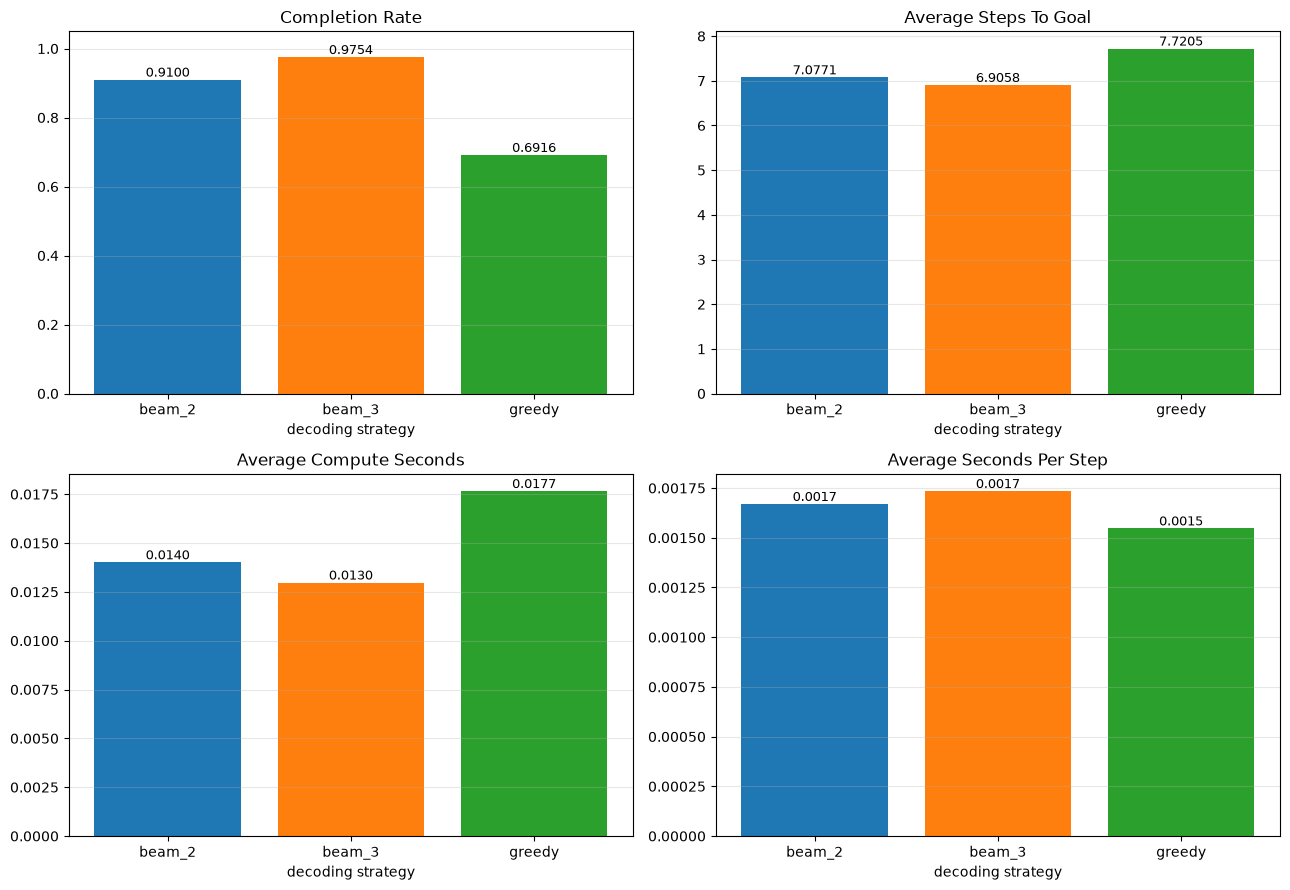

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_specs = [
    ("completion_rate", "Completion Rate"),
    ("average_steps_to_goal", "Average Steps To Goal"),
    ("average_compute_seconds", "Average Compute Seconds"),
    ("average_seconds_per_step", "Average Seconds Per Step"),
]

for ax, (metric, title) in zip(np.asarray(axes).ravel(), metric_specs):
    ax.bar(cv5_summary["strategy"], cv5_summary[metric], color=["tab:blue", "tab:orange", "tab:green"])
    ax.set_title(title)
    ax.set_xlabel("decoding strategy")
    ax.grid(axis="y", alpha=0.3)
    if metric == "completion_rate":
        ax.set_ylim(0.0, 1.05)
    for x_pos, value in enumerate(cv5_summary[metric]):
        ax.text(x_pos, float(value), f"{float(value):.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


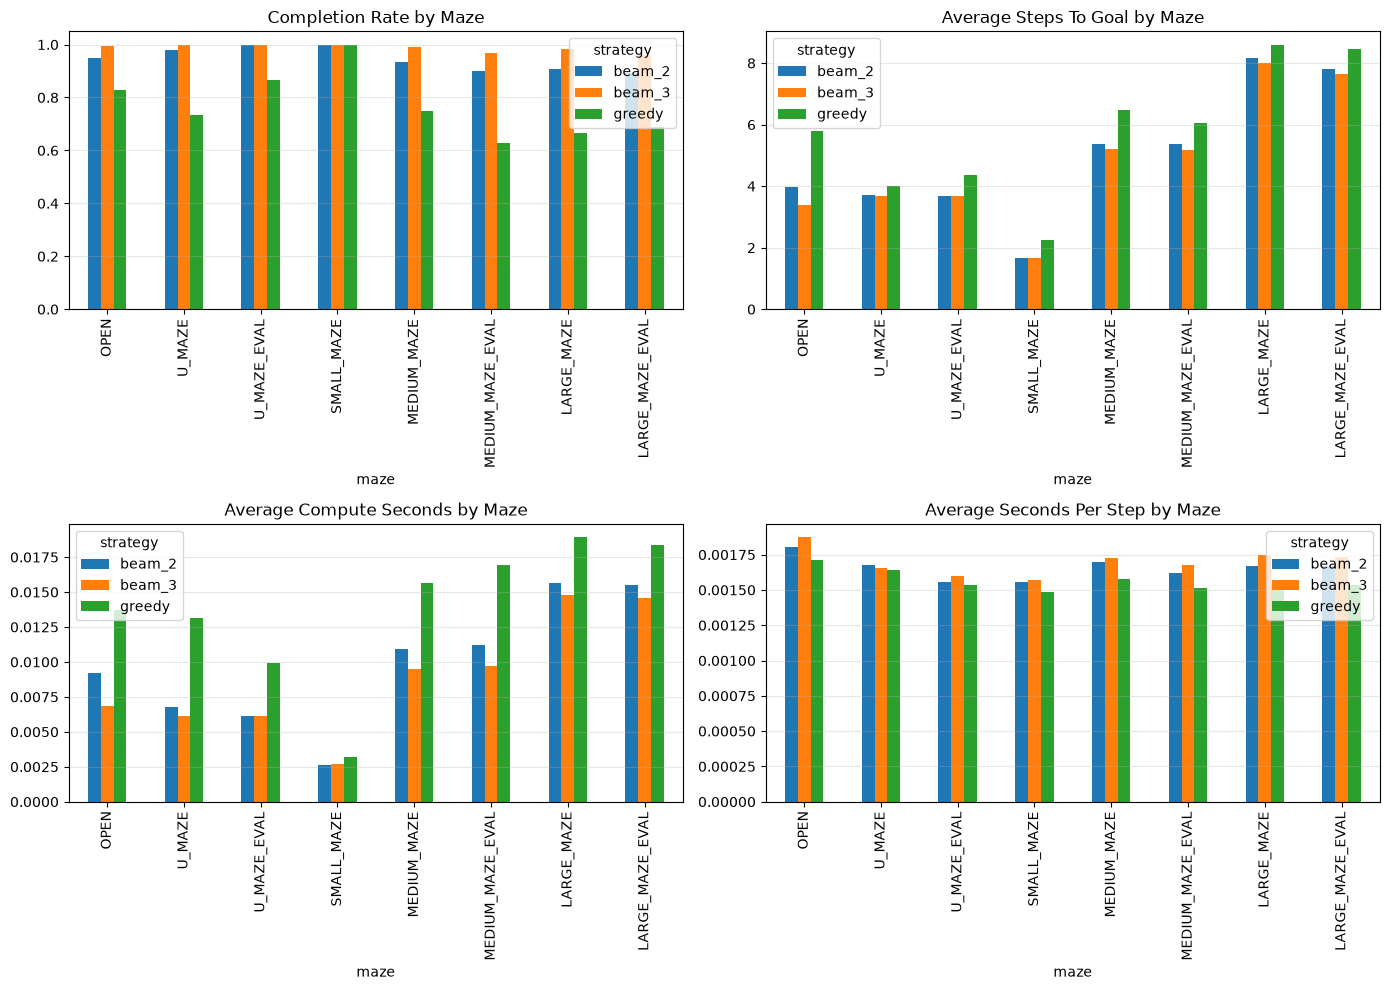

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
per_maze_plot = cv5_per_maze_summary.copy()
metric_specs = [
    ("completion_rate", "Completion Rate"),
    ("average_steps_to_goal", "Average Steps To Goal"),
    ("average_compute_seconds", "Average Compute Seconds"),
    ("average_seconds_per_step", "Average Seconds Per Step"),
]

for ax, (metric, title) in zip(np.asarray(axes).ravel(), metric_specs):
    pivot = per_maze_plot.pivot(index="maze_name", columns="strategy", values=metric).loc[DEFAULT_MAZES]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title + " by Maze")
    ax.set_xlabel("maze")
    ax.grid(axis="y", alpha=0.3)
    if metric == "completion_rate":
        ax.set_ylim(0.0, 1.05)

plt.tight_layout()
plt.show()
